In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Descargar archivo desde GitHub
!wget https://github.com/adiacla/bigdata/raw/refs/heads/master/imagenesvgg16.zip

In [ ]:
# Descomprimir el archivo
!unzip imagenesvgg16.zip

In [ ]:
# Descomprimir en una carpeta específica
!unzip imagenesvgg16.zip -d /content/drive/MyDrive/imagenes/

In [ ]:
from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np


In [ ]:
modelo = DenseNet121(weights='imagenet', include_top=True)

In [ ]:
modelo.summary()

In [ ]:
nuevas_imagenes = ['/content/perro.jpg', '/content/bus.jpg', '/content/vaso.jpg']

imagenesnuevas = np.array([
    preprocess_input(
        img_to_array(
            load_img(img, target_size=(224, 224))
        )
    )
    for img in nuevas_imagenes
])

In [ ]:
import matplotlib.pyplot as plt

nombres = ['Perro', 'Bus', 'Vaso']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (ax, nombre) in enumerate(zip(axes, nombres)):
    # Desnormalizar la imagen para visualizarla correctamente
    img_mostrar = imagenesnuevas[i].copy()
    img_mostrar = img_mostrar - img_mostrar.min()
    img_mostrar = img_mostrar / img_mostrar.max()
    
    ax.imshow(img_mostrar)
    ax.set_title(nombre, fontsize=14)
    ax.axis('off')

plt.suptitle('Imágenes Cargadas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
predicciones = modelo.predict(imagenesnuevas)
resultados = decode_predictions(predicciones, top=3)

nombres = ['Perro', 'Bus', 'Vaso']

for nombre, resultado in zip(nombres, resultados):
    print(f"\n🖼️ Imagen: {nombre}")
    print("-" * 35)
    for i, (id_clase, descripcion, probabilidad) in enumerate(resultado):
        print(f"  Top {i+1}: {descripcion:<20} {probabilidad:.2%}")

**Transfer Learning para perros y gatos**

In [ ]:
import tensorflow as tf

In [ ]:
import tensorflow as tf

# Descargar el dataset
dogs_cats = tf.keras.utils.get_file(
    'dogs_cats',
    origin='https://www.kaggle.com/api/v1/datasets/download/birajsth/cats-and-dogs-filtered',
    extract=True,
    
)

print(dogs_cats)

In [ ]:
import os

# Ver qué hay en la ruta donde se descargó
base_dir = os.path.dirname(dogs_cats)
print("Ruta base:", base_dir)

# Listar archivos y carpetas
for ruta, carpetas, archivos in os.walk(base_dir):
    nivel = ruta.replace(base_dir, '').count(os.sep)
    sangria = ' ' * 2 * nivel
    print(f"{sangria}{os.path.basename(ruta)}/")
    if nivel < 3:  # Solo mostrar 3 niveles de profundidad
        for archivo in archivos:
            print(f"{sangria}  {archivo}")

In [ ]:
base_dir = '/root/.keras/datasets/dogs_cats/cats_and_dogs_filtered'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32
)

print(train_data.class_names)

In [ ]:
import matplotlib.pyplot as plt

nombres_clases = train_data.class_names

fig, axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.flatten()

contador = 0
for imagenes, etiquetas in train_data:
    for i in range(len(imagenes)):
        if contador >= 30:
            break
        axes[contador].imshow(imagenes[i].numpy().astype('uint8'))
        axes[contador].set_title(nombres_clases[etiquetas[i]], fontsize=12)
        axes[contador].axis('off')
        contador += 1
    if contador >= 30:
        break

plt.suptitle('Primeras 30 Imágenes del Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# 1. Averiguamos cuántos lotes (batches) totales tiene el dataset de validación
val_batches = tf.data.experimental.cardinality(val_data)

# 2. Calculamos el 20% de esos lotes (dividiendo entre 5)
test_batches = val_batches // 5

# 3. Creamos el de Prueba (test) tomando ese primer 20%
test_data = val_data.take(test_batches)

# 4. Actualizamos el de Validación saltándonos ese 20% usado, dejando el 80% restante
val_data = val_data.skip(test_batches)

# --- Verificación ---
# Imprimimos la cantidad de lotes finales que quedaron en cada lado
print(f"Lotes en test (20%): {tf.data.experimental.cardinality(test_data).numpy()}")
print(f"Lotes en validación (80%): {tf.data.experimental.cardinality(val_data).numpy()}")

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# 1. Creamos nuestro bloque de Data Augmentation con las transformaciones deseadas
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"), # Voltear horizontalmente
  tf.keras.layers.RandomRotation(0.2),      # Rotar ligeramente
  tf.keras.layers.RandomZoom(0.2),          # Acercar y alejar la imagen
])

# 2. Tomamos el primer lote de imágenes (batch) del dataset de entrenamiento
for images, labels in train_data.take(1):
    
    # Extraemos la primerísima imagen de ese lote
    first_image = images[0]
    
    plt.figure(figsize=(10, 10))
    
    # 3. Le vamos a aplicar la aumentación 9 veces distintas a la MISMA imagen
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # training=True es sumamente importante para que las capas de aumento 
        # se activen (hagan simulaciones aleatorias)
        augmented_image = data_augmentation(tf.expand_dims(first_image, axis=0), training=True)
        
        # Convertimos la imagen de vuelta a tipo entero 'uint8' (0 a 255) para poder imprimirla en matplotlib
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
        
plt.show() # Mostrar gráfico fina

In [ ]:
# 1. Construimos la base del modelo
preprocess_input = tf.keras.applications.densenet.preprocess_input

# 2. Definimos nuestras entradas
inputs = tf.keras.Input(shape=(224, 224, 3))

# 3. Paso de Aumentación de datos (el bloque de la celda que hicimos antes)
x = data_augmentation(inputs)

# 4. Paso de Preprocesamiento EXACTO para DenseNet121
x = preprocess_input(x)

# --- De aquí en adelante agregas el modelo pre-entrenado normal ---
# base_model = tf.keras.applications.DenseNet121(include_top=False, weights='imagenet')
# base_model.trainable = False # Congelar pesos
# x = base_model(x, training=False)

In [43]:
# 1. Indicamos la forma de nuestras imágenes (224x224 píxeles a color RGB)
IMG_SHAPE = (224, 224, 3)

# 2. Instanciamos el modelo base
base_model = tf.keras.applications.DenseNet121(
    input_shape=IMG_SHAPE,
    include_top=False,  # MUY IMPORTANTE: Excluye la capa clasificadora original
    weights='imagenet'  # Usa los pesos de años de entrenamiento previo
)

# 3. Congelamos (freeze) la capa base
# Esto evitará que los valiosos patrones que DenseNet ya aprendió
# se modifiquen o destruyan accidentalmente durante el entrenamiento inicial.
base_model.trainable = False

# 4. Imprime para ver la estructura (opcional)
print("Arquitectura base cargada. N° de capas en el modelo base: ", len(base_model.layers))

# Puedes descomentar la siguiente línea si quieres ver todo el resumen 
# base_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Arquitectura base cargada. N° de capas en el modelo base:  427


In [44]:
# 1. Congelar la base convolucional
base_model.trainable = False

# 2. Comprobación (Verificación)
# Si imprimimos la cantidad de capas/variables que se pueden entrenar en la base, debe darnos cero (0).
print("Variables entrenables (trainable variables) en el modelo base:", len(base_model.trainable_variables))

Variables entrenables (trainable variables) en el modelo base: 0


In [45]:
base_model.summary()

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,037,504 (26.85 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 7,037,504 (26.85 MB)

In [46]:
import tensorflow as tf

# Definimos la capa principal de entrada
inputs = tf.keras.Input(shape=(224, 224, 3))

# 1. Aumentación de datos (las modificaciones aleatorias a la imagen)
x = data_augmentation(inputs)

# 2. Preprocesamiento (Ajustamos los colores al estándar de DenseNet)
x = tf.keras.applications.densenet.preprocess_input(x)

# 3. Modelo base (nuestra red experta en extraer características)
# training=False es para que Keras mantenga las capas internas (Batch Normalization) sin cambios.
x = base_model(x, training=False)

# 4. Promedio de las características extraídas 
# (Convierte los mapas de 2D en un solo vector simplificado)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# 5. Dropout del 20% (Apaga canales aleatoriamente para evitar sobrememorización/overfitting)
x = tf.keras.layers.Dropout(0.2)(x)

# 6. Salida para las 2 clases
# Como es una clasificación binaria (Perro = 0 o Gato = 1), usamos una (1) sola neurona de salida.
outputs = tf.keras.layers.Dense(1)(x)

# --- ENSAMBLADO FINAL ---
# Creamos el nuevo modelo que une el input con todo el flujo hasta el output
model = tf.keras.Model(inputs=inputs, outputs=outputs)

# Volvemos a mirar el resumen, pero esta vez de nuestro modelo completo
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_1 (Add)                     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [48]:
import tensorflow as tf

# 1. Compilación del Modelo
# (Si ya lo compilaste antes en tus apuntes, igual puedes sobreescribirlo aquí sin problema)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
    # from_logits=True es necesario porque nuestra capa Dense(1) no usó una activación 'sigmoid'
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# 2. Iniciar el Entrenamiento y capturar el "History"
epocas = 20

print("⏳ Iniciando entrenamiento. Por favor espera...")

history = model.fit(
    train_data,                 # Las imágenes a estudiar (entrenamiento)
    epochs=epocas,              # Se enseñará a lo largo de 20 ciclos 
    validation_data=val_data    # Verificará la precisión contra el 80% que dejamos para validación
)

print("✅ ¡Entrenamiento completado!")

⏳ Iniciando entrenamiento. Por favor espera...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 31s 287ms/step - accuracy: 0.9155 - loss: 0.2279 - val_accuracy: 0.9653 - val_loss: 0.1377
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.9120 - loss: 0.2209 - val_accuracy: 0.9728 - val_loss: 0.1246
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 215ms/step - accuracy: 0.9245 - loss: 0.1957 - val_accuracy: 0.9765 - val_loss: 0.1089
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 228ms/step - accuracy: 0.9390 - loss: 0.1796 - val_accuracy: 0.9777 - val_loss: 0.1004
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 214ms/step - accuracy: 0.9325 - loss: 0.1792 - val_accuracy: 0.9802 - val_loss: 0.0875
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/step - accuracy: 0.9360 - loss: 0.1637 - val_accuracy: 0.9814 - val_loss: 0.0832
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 231ms/step - accuracy: 0.9355 - loss: 0.1611 - val_accuracy: 0.9802 - val_loss: 0.0766
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 218ms/st

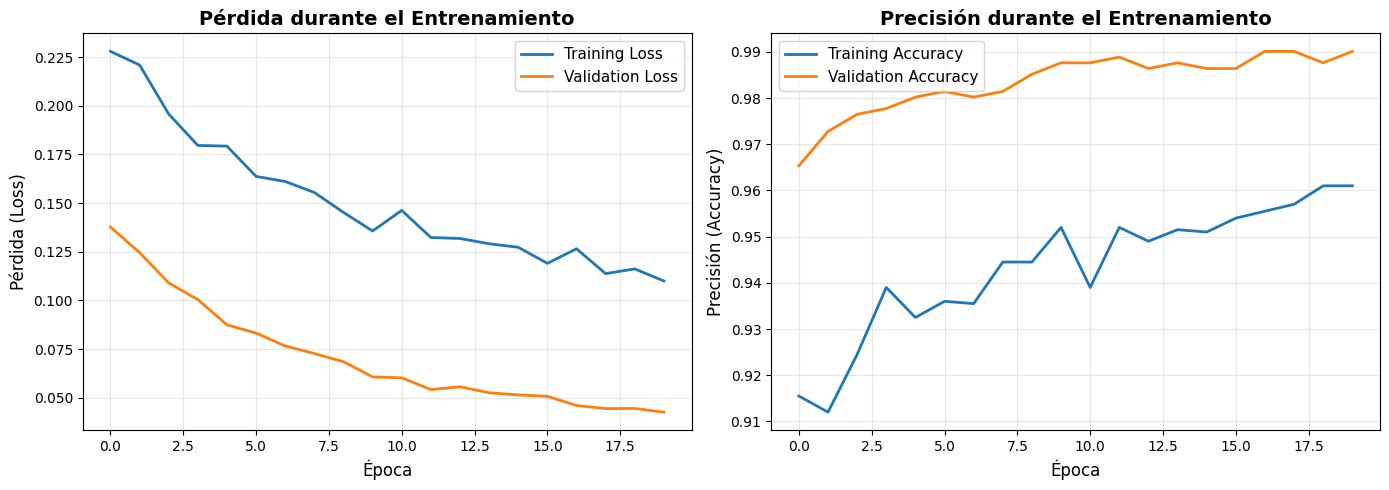


RESUMEN DEL ENTRENAMIENTO
Training Loss Final:      0.1100
Validation Loss Final:    0.0426
Training Accuracy Final:  0.9610
Validation Accuracy Final: 0.9901


In [49]:
import matplotlib.pyplot as plt

# Crear figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. GRÁFICO DE PÉRDIDA (LOSS)
axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Pérdida (Loss)', fontsize=12)
axes[0].set_title('Pérdida durante el Entrenamiento', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 2. GRÁFICO DE PRECISIÓN (ACCURACY)
axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('Precisión (Accuracy)', fontsize=12)
axes[1].set_title('Precisión durante el Entrenamiento', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mostrar valores finales
print("\n" + "="*70)
print("RESUMEN DEL ENTRENAMIENTO")
print("="*70)
print(f"Training Loss Final:      {history.history['loss'][-1]:.4f}")
print(f"Validation Loss Final:    {history.history['val_loss'][-1]:.4f}")
print(f"Training Accuracy Final:  {history.history['accuracy'][-1]:.4f}")
print(f"Validation Accuracy Final: {history.history['val_accuracy'][-1]:.4f}")
print("="*70)

REALIZANDO PREDICCIONES EN CONJUNTO DE TEST
Umbral de confianza: 70%

Total de predicciones: 192

✅ Predicciones CORRECTAS:    192 (100.0%)
❓ Predicciones CON DUDAS:    5 (2.6%)
❌ Predicciones INCORRECTAS:  0 (0.0%)

EJEMPLOS DETALLADOS (Primeras 15)

Muestra 1:
  Clase Real:       dogs
  Probabilidades:   cats: 3.00% | dogs: 97.00%
  Predicción:       ✅ DOGS (Confianza: 97.00%)

Muestra 2:
  Clase Real:       dogs
  Probabilidades:   cats: 0.34% | dogs: 99.66%
  Predicción:       ✅ DOGS (Confianza: 99.66%)

Muestra 3:
  Clase Real:       cats
  Probabilidades:   cats: 99.62% | dogs: 0.38%
  Predicción:       ✅ CATS (Confianza: 99.62%)

Muestra 4:
  Clase Real:       cats
  Probabilidades:   cats: 97.88% | dogs: 2.12%
  Predicción:       ✅ CATS (Confianza: 97.88%)

Muestra 5:
  Clase Real:       cats
  Probabilidades:   cats: 99.71% | dogs: 0.29%
  Predicción:       ✅ CATS (Confianza: 99.71%)

Muestra 6:
  Clase Real:       cats
  Probabilidades:   cats: 99.10% | dogs: 0.90%
  Predicci

/tmp/ipykernel_12066/812873466.py:123: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12066/812873466.py:123: UserWarning: Glyph 10067 (\N{BLACK QUESTION MARK ORNAMENT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


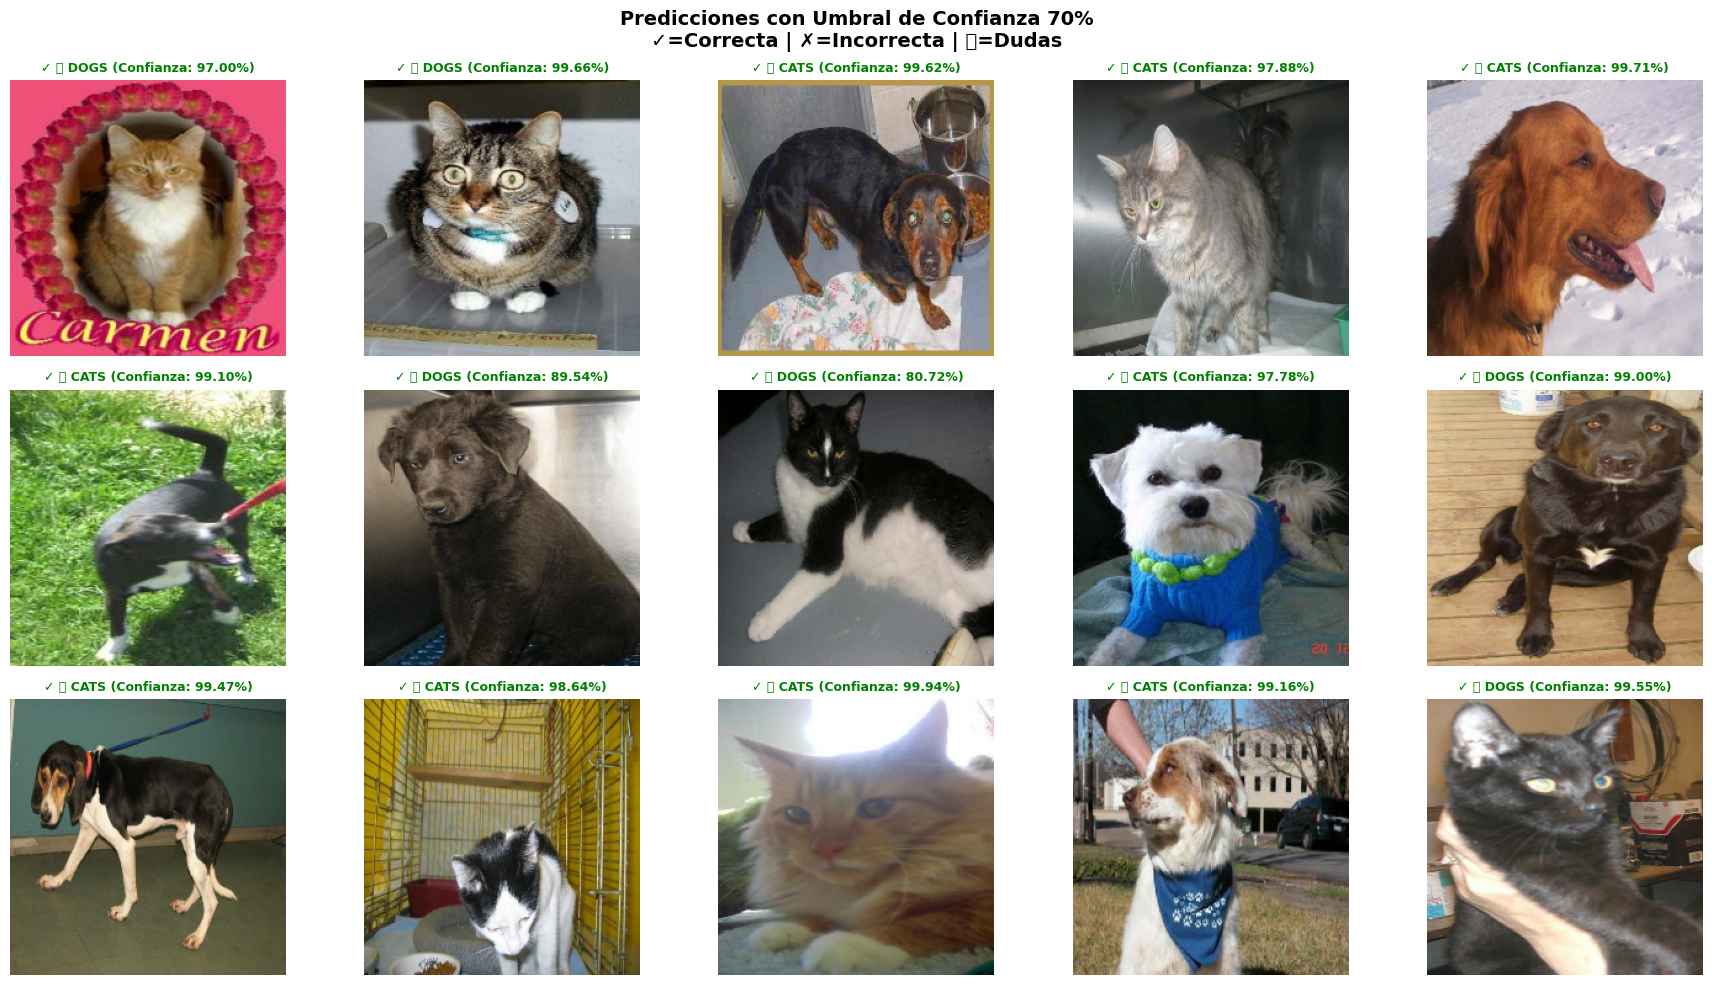


✅ PREDICCIONES COMPLETADAS


In [51]:
import numpy as np
import matplotlib.pyplot as plt

# 1. HACER PREDICCIONES EN EL CONJUNTO DE TEST
print("="*70)
print("REALIZANDO PREDICCIONES EN CONJUNTO DE TEST")
print("="*70)

umbral = 0.7  # 70%

# 2. RECOLECTAR TODAS LAS PREDICCIONES Y ETIQUETAS
todas_predicciones = []
todas_etiquetas = []

for imagenes, etiquetas in test_data:
    preds = model.predict(imagenes, verbose=0)
    todas_predicciones.extend(preds.flatten())
    todas_etiquetas.extend(etiquetas.numpy())

# Convertir a arrays
todas_predicciones = np.array(todas_predicciones)
todas_etiquetas = np.array(todas_etiquetas)

# 3. EXTRAER PROBABILIDADES PARA AMBAS CLASES
nombres_clases = train_data.class_names  # ['cats', 'dogs']
resultados = []

print(f"Umbral de confianza: {umbral*100:.0f}%\n")

for pred, etiqueta_real in zip(todas_predicciones, todas_etiquetas):
    # Convertir logit a probabilidad (sigmoid)
    prob_clase_1 = 1 / (1 + np.exp(-pred))  # Probabilidad de la clase 1 (dogs)
    prob_clase_0 = 1 - prob_clase_1         # Probabilidad de la clase 0 (cats)
    
    # Encontrar la clase con MAYOR probabilidad
    probabilidades = [prob_clase_0, prob_clase_1]
    clase_predicha = np.argmax(probabilidades)
    confianza_maxima = probabilidades[clase_predicha]
    
    # Aplicar umbral del 70%
    if confianza_maxima > umbral:
        nombre_clase = nombres_clases[clase_predicha].upper()
        clasificacion = f"✅ {nombre_clase} (Confianza: {confianza_maxima:.2%})"
    else:
        clasificacion = f"❓ DUDAS (Confianza baja: {confianza_maxima:.2%})"
    
    correcto = clase_predicha == etiqueta_real
    
    resultados.append({
        'prob_clase_0': prob_clase_0,
        'prob_clase_1': prob_clase_1,
        'clase_predicha': clase_predicha,
        'etiqueta_real': etiqueta_real,
        'correcto': correcto,
        'confianza': confianza_maxima,
        'clasificacion': clasificacion
    })

# 4. MOSTRAR RESULTADOS
print(f"Total de predicciones: {len(resultados)}\n")

predicciones_correctas = sum(1 for r in resultados if r['correcto'])
predicciones_dudas = sum(1 for r in resultados if 'DUDAS' in r['clasificacion'])
predicciones_incorrectas = sum(1 for r in resultados if not r['correcto'] and 'DUDAS' not in r['clasificacion'])

print(f"✅ Predicciones CORRECTAS:    {predicciones_correctas} ({predicciones_correctas/len(resultados)*100:.1f}%)")
print(f"❓ Predicciones CON DUDAS:    {predicciones_dudas} ({predicciones_dudas/len(resultados)*100:.1f}%)")
print(f"❌ Predicciones INCORRECTAS:  {predicciones_incorrectas} ({predicciones_incorrectas/len(resultados)*100:.1f}%)")

# 5. MOSTRAR ALGUNOS EJEMPLOS CON DETALLES
print("\n" + "="*70)
print("EJEMPLOS DETALLADOS (Primeras 15)")
print("="*70)

for i, resultado in enumerate(resultados[:15]):
    class_real = nombres_clases[resultado['etiqueta_real']]
    print(f"\nMuestra {i+1}:")
    print(f"  Clase Real:       {class_real}")
    print(f"  Probabilidades:   {nombres_clases[0]}: {resultado['prob_clase_0']:.2%} | {nombres_clases[1]}: {resultado['prob_clase_1']:.2%}")
    print(f"  Predicción:       {resultado['clasificacion']}")

# 6. VISUALIZAR EJEMPLOS CON IMÁGENES
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

contador = 0
for imagenes, etiquetas in test_data:
    for i in range(len(imagenes)):
        if contador >= 15:
            break
        
        ax = axes[contador]
        
        idx = contador
        if idx < len(resultados):
            resultado = resultados[idx]
            
            # Mostrar imagen
            img_mostrar = imagenes[i].numpy().astype('uint8')
            ax.imshow(img_mostrar)
            
            # Definir color y título según clasificación
            if 'DUDAS' in resultado['clasificacion']:
                color = 'orange'
                titulo = resultado['clasificacion']
            elif resultado['correcto']:
                color = 'green'
                titulo = f"✓ {resultado['clasificacion']}"
            else:
                color = 'red'
                titulo = f"✗ {resultado['clasificacion']}"
            
            ax.set_title(titulo, fontsize=9, color=color, fontweight='bold', wrap=True)
            ax.axis('off')
        
        contador += 1
    
    if contador >= 15:
        break

plt.suptitle(f'Predicciones con Umbral de Confianza {umbral*100:.0f}%\n✓=Correcta | ✗=Incorrecta | ❓=Dudas', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("✅ PREDICCIONES COMPLETADAS")
print("="*70)